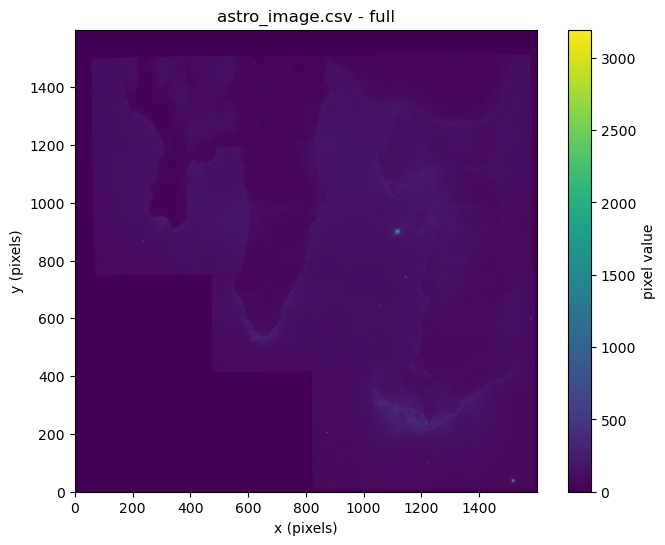

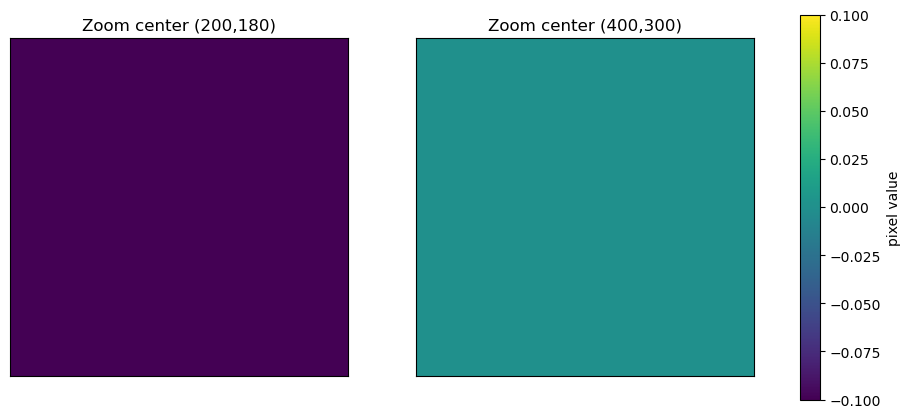

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# load CSV assuming comma separated numeric grid
data = np.loadtxt("astro_image.csv")

# full-image plot with colorbar
plt.figure(figsize=(8,6))
im = plt.imshow(data, origin="lower", cmap="viridis", aspect="equal")
plt.colorbar(im, label="pixel value")
plt.title("astro_image.csv - full")
plt.xlabel("x (pixels)")
plt.ylabel("y (pixels)")
plt.show()

# two side-by-side zooms on interesting feature: pick centers manually
fig, axes = plt.subplots(1,2, figsize=(12,5))
# choose two zoom centers and size (adjust after inspecting image)
centers = [(200,180),(400,300)]   # example coordinates
zoom = 60
for ax,(cx,cy) in zip(axes, centers):
    x0 = max(0,int(cx-zoom))
    x1 = min(data.shape[1], int(cx+zoom))
    y0 = max(0,int(cy-zoom))
    y1 = min(data.shape[0], int(cy+zoom))
    im2 = ax.imshow(data[y0:y1, x0:x1], origin="lower", aspect="equal")
    ax.set_title(f"Zoom center ({cx},{cy})")
    ax.set_xticks([])
    ax.set_yticks([])
fig.colorbar(im2, ax=axes.ravel().tolist(), label="pixel value")
plt.show()


In [3]:
#3.2 Pandas and Ramen

In [8]:

import pandas as pd


df = pd.read_csv("ramen-ratings.csv")
df.head()

# 1. Columns
print("Columns:", df.columns.tolist())

# 2. Style of 27th entry (index 26)
print("27th style:", df.iloc[26]["Style"])

# 3. Number of unique brands
print("Unique brands:", df["Brand"].nunique())

# 4. Sort dataset by brand name
df_sorted = df.sort_values("Brand").reset_index(drop=True)
display(df_sorted.head(20))

# 5. Ramen brands made in the USA
usa_df = df[df["Country"] == "USA"]
print("USA entries:", len(usa_df))
print("Unique USA brands:", usa_df["Brand"].nunique())

# 6. USA brands that make pack-style ramen
usa_pack = usa_df[usa_df["Style"].str.lower().str.contains("pack", na=False)]
print("USA pack entries:", len(usa_pack))
print("USA pack unique brands:", usa_pack["Brand"].nunique())

# 7. Brands that have been in the top ten
top_ten_col = [c for c in df.columns if "Top" in c and "Ten" in c]

if top_ten_col:
    col = top_ten_col[0]
    top_brands = df[df[col].notna()]["Brand"].unique().tolist()
    print("Brands in top ten:", top_brands)
else:
    print("No 'Top Ten' column found; available columns:", df.columns.tolist())


Columns: ['Review #', 'Brand', 'Variety', 'Style', 'Country', 'Stars', 'Top Ten']
27th style: Pack
Unique brands: 355


,Review #,Brand,Variety,Style,Country,Stars,Top Ten
0,2351,1 To 3 Noodles,Chatpat Masala,Pack,India,4,NaN
1,2124,7 Select,Nissin Instant Noodles Tom Yum Seafood Creamy ...,Bowl,Thailand,3.5,NaN
2,2117,7 Select,Nissin Instant Noodles Shrimp Ma Nao Lui Suan ...,Bowl,Thailand,4,NaN
3,1703,7 Select/Nissin,Super Tom Yum Shrimp,Cup,Thailand,3.5,NaN
4,1669,A-One,Mi Ly Instant Noodles Mi Chay Vegetarian Flavor,Cup,Vietnam,1.25,NaN
5,1633,A-One,Mi Ly Instant Noodles Mi Bo Beef Flavor,Cup,Vietnam,3.5,NaN
6,1564,A-One,Mì Ly Instant Noodles Mì Thịt Xào Pork Flavor,Cup,Vietnam,3,NaN
7,1291,A-One,Mì Ly Instant Noodles Mì Tôm Shrimp Flavor,Cup,Vietnam,3.25,NaN
8,1328,A-Sha Dry Noodle,Hello Kitty La Wei (Spicy Flavor),Pack,Taiwan,3.75,NaN
9,2156,A-Sha Dry Noodle,Chow Mein Oyster Sauce BBQ Flavor,Tray,Taiwan,2,NaN


USA entries: 323
Unique USA brands: 49
USA pack entries: 128
USA pack unique brands: 27
Brands in top ten: ['MAMA', 'Prima Taste', 'Prima', 'Tseng Noodles', 'Wugudaochang', 'A-Sha Dry Noodle', 'MyKuali', 'CarJEN', 'Maruchan', 'Mamee', 'Mama', 'Sapporo Ichiban', 'Nongshim', 'Samyang Foods', 'Paldo', 'Indomie', 'Koka', 'Mi Sedaap', 'Nissin', 'Myojo', 'Doll']


Index(['CCl4ottoyr', 'CCl4ottomon', 'CCl4ottoNHm', 'CCl4ottoNHsd',
       'CCl4ottoSHm', 'CCl4ottoSHsd', 'CCl4ottoGLm', 'CCl4ottoGLsd'],
      dtype='object')


/var/folders/dr/5_9cfn154vv2r5fwd0n8ktm00000gn/T/ipykernel_70688/1150323431.py:24: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("global_CCl4_MM (1).dat",


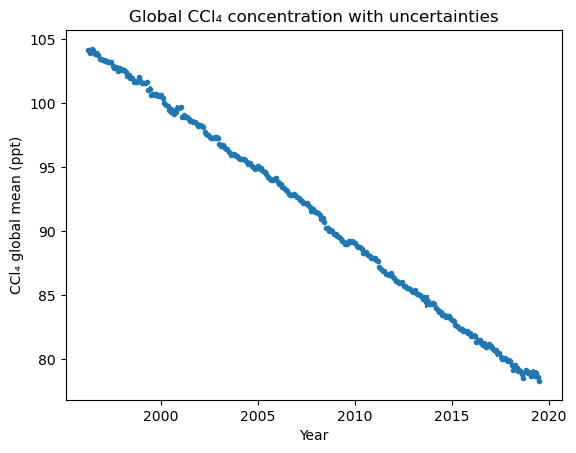

slope = -1.1544097066171286
intercept = 2409.219208350417
reduced chi-square: 4.436832249146349


In [7]:
from astropy.table import Table
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial
from scipy import stats

# 1. Load data
t = Table.read("global_CCl4_MM (1).dat", format="ascii")
# 2. Convert to DataFrame and pick columns
df = t.to_pandas()
# Inspect column names
print(df.columns)



df["date"] = df["CCl4ottoyr"] + (df["CCl4ottomon"]-1)/12
df_small = df[["date", "CCl4ottoGLm", "CCl4ottoGLsd"]].dropna()

x = df_small["date"].values
y = df_small["CCl4ottoGLm"].values
sigma = df_small["CCl4ottoGLsd"].values

df = pd.read_csv("global_CCl4_MM (1).dat",
                 delim_whitespace=True,
                 comment='#')

df["date"] = df["CCl4ottoyr"] + (df["CCl4ottomon"]-1)/12
df_small = df[["date", "CCl4ottoGLm", "CCl4ottoGLsd"]].dropna()

x = df_small["date"].values
y = df_small["CCl4ottoGLm"].values
sigma = df_small["CCl4ottoGLsd"].values

plt.errorbar(x, y, yerr=sigma, fmt='o', markersize=3)
plt.xlabel("Year")
plt.ylabel("CCl₄ global mean (ppt)")
plt.title("Global CCl₄ concentration with uncertainties")
plt.show()

coeffs = np.polyfit(x, y, deg=1, w=1/sigma)
m, b = coeffs

print("slope =", m)
print("intercept =", b)

yexp = np.polyval(coeffs, x)

chi2 = np.sum(((y - yexp)**2) / (sigma**2))
redir = chi2 / (len(x) - 2)

print("reduced chi-square:", redir)

